# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

# Experiment 2B - Why does frequency matter?

## A/B/C/D definitions

A: Native observations represented on the standard 1h grid.

B: Structured r-hour measurement selection/thinning; retained observations keep original timestamps and are represented on the downstream 1h grid.

C: Random matched-count thinning; for each patient-variable, retain the same effective number of observations as B but choose positions randomly from originally occupied 1h cells. Downstream representation remains 1h.

D: Standard r-hour discretization using the ordinary r-hour grid and therefore fewer recurrent steps.

Question: Which parts of the frequency effect are associated with structured observation loss, temporal placement, and representation/grid changes?

Evidence we are looking for: A > B suggests structured observation loss removes predictive information; B != C suggests temporal placement matters beyond observation count; B != D suggests representation/grid effects matter in addition to selection.

Caveat: A/B/C/D are not an additive causal decomposition. B vs D is not a pure sequence-length contrast because temporal alignment, masks/imputation trajectories, temporal precision, and representation resolution also change.

## Run availability / diagnostics

The code below preserves the strict provenance chain: validation log -> validation-AUPRC-selected epoch -> exact checkpoint filename -> exact test prediction filename.

In [1]:
REQUIRE_COMPLETE_FOR_FINAL = True
# Missing test predictions are always generated automatically.
# Set this to True only when intentionally regenerating ALL test predictions.
RERUN_ALL_TEST_INFERENCE = False

In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

_EXP2B_REPO_IMPORT_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
if str(_EXP2B_REPO_IMPORT_DIR) not in sys.path:
    sys.path.insert(0, str(_EXP2B_REPO_IMPORT_DIR))

from mimic4benchmark.readers import FixedHorizonIcuExitReader
from mimic4models.fixed_horizon_icu_exit.matched_count_control.sampling import SamplingReader

from visualize_utils import (
    characterize_reader_input_information,
    compute_metric,
    find_selected_checkpoint,
    load_prediction_csv,
    metric_difference,
    across_seed_patient_bootstrap,
    paired_patient_bootstrap,
    paired_prediction_frame,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
    test_metrics,
)

# ============================================================
# Configuration
# ============================================================

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/length-of-stay"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit"
)

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

EXP2B_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
NETWORK = "mimic4models/keras_models/lstm.py"
EXP2B_OUTPUT_DIR = OUT / "plots"
EXP2B_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Primary matched-count configuration.
TARGET_RS = [4]
HORIZONS = [12, 24, 48, 96, 168]
EXPECTED_MODEL_SEEDS = [0, 1, 2, 3, 4]
EXPECTED_EPOCHS = 100

print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible test predictions will be regenerated.")

N_BOOT = int(os.environ.get("EXP2B_N_BOOT", "2000"))
BOOTSTRAP_SEED = 12345

EXPECTED_CONFIG = {
    "network": NETWORK,
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_size": 8,
    "epochs": 100,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "sampling_seed": 100,
}

CONDITION_ORDER = ["A", "B", "C", "D"]
PRIMARY_CONTRASTS = [("A", "B"), ("B", "C"), ("B", "D")]
OPTIONAL_CONTRASTS = [("A", "D")]
METRICS = ["auroc", "auprc", "brier"]


Missing test predictions: AUTO-RUN
Rerun all existing test predictions: False


### Input-information characterization

Structured thinning is introduced here at `r=4`. The table below summarizes retained observed variable values, occupied 1-hour bins with real observations, observed channels, and the fixed post-discretization sequence length sanity check. It does not add `r=8` to Exp2B/C.


In [3]:
# ============================================================
# Exp2B/C input-information characterization: dense vs structured r=4
# ============================================================

EXP2B_INPUT_CHARACTERIZATION_R = 4
if TARGET_RS != [EXP2B_INPUT_CHARACTERIZATION_R]:
    raise RuntimeError("Exp2B/C input characterization expects TARGET_RS == [4], got {}".format(TARGET_RS))


def build_exp2b_characterization_reader(condition):
    reader = FixedHorizonIcuExitReader(
        dataset_dir=str(DATA / "test"),
        listfile=str(DATA / "test_listfile.csv"),
        horizon=HORIZONS[0],
    )
    if condition == "dense":
        return reader
    if condition == "structured-r4":
        return SamplingReader(
            reader,
            strategy="structured",
            sampling_interval=EXP2B_INPUT_CHARACTERIZATION_R,
            sampling_seed=None,
        )
    raise ValueError("Unknown Exp2B/C characterization condition {}".format(condition))


exp2b_input_information_stay_level, exp2b_input_information_summary, exp2b_input_information_channel_retention = characterize_reader_input_information(
    [
        ("dense", np.nan, build_exp2b_characterization_reader("dense")),
        ("structured-r4", EXP2B_INPUT_CHARACTERIZATION_R, build_exp2b_characterization_reader("structured-r4")),
    ],
    dense_condition="dense",
)

exp2b_input_information_cols = [
    "condition", "n_stays",
    "mean_token_count", "median_token_count", "p25_token_count", "p75_token_count", "p95_token_count",
    "mean_token_retained_fraction", "median_token_retained_fraction",
    "mean_occupied_1h_bins", "median_occupied_1h_bins",
    "mean_channels_observed", "median_channels_observed",
    "post_discretization_sequence_length",
]
exp2b_input_information_summary = exp2b_input_information_summary[exp2b_input_information_cols]
show_table("Exp2B/C input-information characterization: dense vs structured r=4", exp2b_input_information_summary, max_rows=20)
show_table("Exp2B/C per-channel token retention: dense vs structured r=4", exp2b_input_information_channel_retention, max_rows=200)
print("Verified dense and structured-r4 use identical stay names/order.")




Exp2B/C input-information characterization: dense vs structured r=4


,condition,n_stays,mean_token_count,median_token_count,p25_token_count,p75_token_count,p95_token_count,mean_token_retained_fraction,median_token_retained_fraction,mean_occupied_1h_bins,median_occupied_1h_bins,mean_channels_observed,median_channels_observed,post_discretization_sequence_length
0,dense,6757,70.706527,9.0,3.0,168.0,251.0,1.000000,1.00,10.381086,6.0,5.211188,3.0,24
1,structured-r4,6757,22.729022,7.0,3.0,51.0,70.0,0.684687,0.75,6.838686,5.0,5.211188,3.0,24



Exp2B/C per-channel token retention: dense vs structured r=4


,channel,mean_dense_token_count,mean_r4_token_count,r4_retained_fraction
0,Oxygen saturation,9.620246,2.325292,0.241708
1,Respiratory rate,9.039515,1.897736,0.209938
2,Heart Rate,8.946130,1.899808,0.212361
3,Mean blood pressure,8.897588,1.894036,0.212871
4,Systolic blood pressure,8.890336,1.894480,0.213094
5,Diastolic blood pressure,8.888708,1.894332,0.213117
6,Glucose,4.548912,2.887820,0.634837
7,pH,2.967293,1.914459,0.645187
8,Temperature,2.565044,1.708450,0.666051
9,Glascow coma scale eye opening,1.620098,1.115140,0.688316


Verified dense and structured-r4 use identical stay names/order.


In [4]:
# ============================================================
# Robust run parsing and exact checkpoint/prediction matching
# ============================================================

def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    if cast is not None:
        return cast(value)
    return value


def parse_run_from_filename(path, target_r):
    """Parse validation log/checkpoint/prediction identity from a filename."""
    name = path.name
    horizon = _search(r"\.h(\d+)", name, int)
    timestep = _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float)
    model_seed = _search(r"\.seed(\d+)(?:\.|$)", name, int)

    dim = _search(r"\.n(\d+)", name, int)
    dropout = _search(r"\.d([0-9.]+)\.dep", name, float)
    depth = _search(r"\.dep(\d+)", name, int)
    batch_size = _search(r"\.bs(\d+)", name, int)
    target_repl_coef = _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0)
    has_l1 = re.search(r"\.L1[0-9.eE+-]+", name) is not None
    has_l2 = re.search(r"\.L2[0-9.eE+-]+", name) is not None

    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        sampling_strategy = "none"
        sampling_interval = None
        sampling_seed = None
    else:
        sampling_strategy = sample.group("strategy")
        sampling_interval = int(sample.group("interval"))
        sampling_seed = sample.group("sseed")
        sampling_seed = int(sampling_seed) if sampling_seed is not None else None

    condition = None
    r = target_r
    if sampling_strategy == "none" and timestep is not None and abs(timestep - 1.0) < 1e-6:
        condition = "A"
        r = target_r
    elif (sampling_strategy == "structured" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "B"
        r = sampling_interval
    elif (sampling_strategy == "random_matched" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "C"
        r = sampling_interval
    elif (sampling_strategy == "none" and timestep is not None
          and abs(timestep - float(target_r)) < 1e-6):
        condition = "D"
        r = target_r

    return {
        "filename": name,
        "horizon": horizon,
        "r": r,
        "condition": condition,
        "timestep": timestep,
        "model_seed": model_seed,
        "dim": dim,
        "depth": depth,
        "dropout": dropout,
        "batch_size": batch_size,
        "sampling_strategy": sampling_strategy,
        "sampling_interval": sampling_interval,
        "sampling_seed": sampling_seed,
        "target_repl_coef": target_repl_coef,
        "has_l1": has_l1,
        "has_l2": has_l2,
    }


def hyperparameter_mismatch_reason(run):
    reasons = []
    checks = [
        ("dim", EXPECTED_CONFIG["dim"]),
        ("depth", EXPECTED_CONFIG["depth"]),
        ("batch_size", EXPECTED_CONFIG["batch_size"]),
    ]
    for key, expected in checks:
        if run.get(key) != expected:
            reasons.append("{}={} expected {}".format(key, run.get(key), expected))
    if run.get("dropout") is None or abs(run.get("dropout") - EXPECTED_CONFIG["dropout"]) > 1e-9:
        reasons.append("dropout={} expected {}".format(run.get("dropout"), EXPECTED_CONFIG["dropout"]))
    if run.get("target_repl_coef") != EXPECTED_CONFIG["target_repl_coef"]:
        reasons.append("target_repl_coef={} expected {}".format(
            run.get("target_repl_coef"), EXPECTED_CONFIG["target_repl_coef"]))
    if run.get("has_l1"):
        reasons.append("L1 suffix present; expected l1=0")
    if run.get("has_l2"):
        reasons.append("L2 suffix present; expected l2=0")
    if run.get("condition") == "C" and run.get("sampling_seed") != EXPECTED_CONFIG["sampling_seed"]:
        reasons.append("sampling_seed={} expected {}".format(
            run.get("sampling_seed"), EXPECTED_CONFIG["sampling_seed"]))
    if run.get("model_seed") not in EXPECTED_MODEL_SEEDS:
        reasons.append(
            "model_seed={} not in expected {}".format(
                run.get("model_seed"),
                EXPECTED_MODEL_SEEDS,
            )
        )        
    return "; ".join(reasons)


def condition_description(condition):
    if condition == "A":
        return "standard 1h"
    if condition == "B":
        return "structured-r + 1h"
    if condition == "C":
        return "random matched-count-r + 1h"
    if condition == "D":
        return "existing r-hour representation"
    return "outside A/B/C/D"


def exact_prediction_path(checkpoint, run_output_dir):
    pred_dir = Path(run_output_dir) / "test_predictions"
    expected_name = checkpoint.name + ".csv"
    if not pred_dir.exists():
        return pred_dir / expected_name, []
    matches = [p for p in pred_dir.iterdir() if p.name == expected_name]
    if len(matches) > 1:
        raise RuntimeError("Multiple exact prediction files for checkpoint {}:\n{}".format(
            checkpoint.name, matches))
    return pred_dir / expected_name, matches


def find_normalizer_for_run(run):
    if run["condition"] == "C":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), int(run["sampling_seed"]), float(run["timestep"]))
    elif run["condition"] == "B":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), float(run["timestep"]))
    else:
        pattern = (
            "fixed_horizon_icu_exit_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(float(run["timestep"]))
    candidates = sorted(NORM.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def build_test_inference_command(run, checkpoint, prediction_path):
    normalizer = find_normalizer_for_run(run)
    output_dir = Path(run["run_output_dir"])
    cmd = [
        "python", "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(DATA),
        "--output_dir", str(output_dir),
        "--normalizer_state", str(normalizer),
        "--load_state", str(checkpoint),
        "--horizon", str(int(run["horizon"])),
        "--timestep", str(float(run["timestep"])),
        "--seed", str(int(run["model_seed"])),
        "--dim", str(EXPECTED_CONFIG["dim"]),
        "--depth", str(EXPECTED_CONFIG["depth"]),
        "--dropout", str(EXPECTED_CONFIG["dropout"]),
        "--rec_dropout", str(EXPECTED_CONFIG["rec_dropout"]),
        "--batch_size", str(EXPECTED_CONFIG["batch_size"]),
        "--lr", str(EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXPECTED_CONFIG["beta_1"]),
        "--l1", str(EXPECTED_CONFIG["l1"]),
        "--l2", str(EXPECTED_CONFIG["l2"]),
        "--target_repl_coef", str(EXPECTED_CONFIG["target_repl_coef"]),
        "--sampling_strategy", run["sampling_strategy"],
    ]
    if run["condition"] in ("B", "C"):
        cmd += ["--sampling_interval", str(int(run["sampling_interval"]))]
    if run["condition"] == "C":
        cmd += ["--sampling_seed", str(int(run["sampling_seed"]))]
    return cmd


def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def run_test_inference_for_prediction(run, checkpoint, prediction_path):
    cmd = build_test_inference_command(run, checkpoint, prediction_path)
    if prediction_path.exists():
        if not RERUN_ALL_TEST_INFERENCE:
            return
        print("RERUN_ALL_TEST_INFERENCE=True")
        print("Regenerating existing prediction:")
        print(prediction_path)
        print(quote_command(cmd))
    else:
        print("Missing test prediction; running inference:")
        print(prediction_path)
        print(quote_command(cmd))
    subprocess.check_call(cmd, cwd=str(EXP2B_REPO_DIR))
    if not prediction_path.exists():
        raise RuntimeError("Test inference completed but exact prediction file is missing: {}".format(prediction_path))

In [5]:
def expected_exp2b_output_dir(parsed):
    horizon = int(parsed["horizon"])
    r = int(parsed["r"])
    condition = parsed["condition"]

    if condition in ("A", "D"):
        return OUT / "{}h".format(horizon)

    if condition == "B":
        return (
            OUT
            / "structured"
            / "{}h".format(horizon)
            / "{}h".format(r)
        )

    if condition == "C":
        return (
            OUT
            / "random_matched"
            / "{}h".format(horizon)
            / "{}h".format(r)
        )

    return None

In [6]:
# ============================================================
# Discover validation logs, select checkpoints, and load exact test predictions
# ============================================================

status_rows = []
excluded_rows = []
partial_rows = []
missing_prediction_rows = []
included_rows = []
prediction_frames = {}
discovered_condition_counts = {condition: 0 for condition in CONDITION_ORDER}

for target_r in TARGET_RS:
    for log_path in sorted(OUT.rglob("keras_logs/*.csv")):
        parsed = parse_run_from_filename(log_path, target_r)
        if parsed["horizon"] not in HORIZONS:
            continue
        run_output_dir = log_path.parent.parent

        expected_dir = expected_exp2b_output_dir(parsed)

        if expected_dir is None or run_output_dir.resolve() != expected_dir.resolve():
            row = dict(parsed)
            row["run_output_dir"] = str(run_output_dir)
            row["exclude_reason"] = (
                "wrong output directory for Exp2B; expected {}".format(expected_dir)
            )
            excluded_rows.append(row)
            continue
        
        parsed["run_output_dir"] = str(run_output_dir)
        parsed["log_path"] = str(log_path)
        parsed["condition_description"] = condition_description(parsed["condition"])
        if parsed["condition"] in discovered_condition_counts:
            discovered_condition_counts[parsed["condition"]] += 1

        if parsed["condition"] is None:
            row = dict(parsed)
            row["exclude_reason"] = "outside A/B/C/D for r={}".format(target_r)
            excluded_rows.append(row)
            continue

        mismatch = hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            excluded_rows.append(row)
            continue

        val = read_validation_log(log_path)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            excluded_rows.append(row)
            continue
        parsed.update(val)

        checkpoint = find_selected_checkpoint(log_path, parsed["best_val_epoch"])
        parsed["selected_val_epoch"] = parsed["best_val_epoch"]
        parsed["val_auprc"] = parsed["best_val_auprc"]
        parsed["val_auroc"] = parsed["val_auroc_at_best_auprc"]
        parsed["selected_checkpoint"] = str(checkpoint) if checkpoint is not None else None
        parsed["checkpoint"] = str(checkpoint) if checkpoint is not None else None

        status_rows.append(dict(parsed))

        if not parsed["complete"]:
            partial_rows.append(dict(parsed))
            if REQUIRE_COMPLETE_FOR_FINAL:
                continue

        if checkpoint is None:
            row = dict(parsed)
            row["missing_reason"] = "MISSING SELECTED CHECKPOINT"
            missing_prediction_rows.append(row)
            continue

        expected_prediction, matches = exact_prediction_path(checkpoint, parsed["run_output_dir"])
        parsed["prediction_path"] = str(expected_prediction)

        if len(matches) == 0 or RERUN_ALL_TEST_INFERENCE:
            run_test_inference_for_prediction(parsed, checkpoint, expected_prediction)
            expected_prediction, matches = exact_prediction_path(checkpoint, parsed["run_output_dir"])
        if len(matches) == 0:
            row = dict(parsed)
            row["missing_reason"] = "MISSING TEST PREDICTION"
            missing_prediction_rows.append(row)
            continue

        pred_path = expected_prediction
        pred_df = load_prediction_csv(pred_path)
        metrics = test_metrics(pred_df)
        parsed.update(metrics)
        parsed["prediction_path"] = str(pred_path)

        key = (parsed["horizon"], parsed["r"], parsed["condition"], parsed["model_seed"])
        if key in prediction_frames:
            raise RuntimeError("Duplicate included run identity {}. Refusing to mix runs.".format(key))
        prediction_frames[key] = pred_df
        included_rows.append(dict(parsed))

status_df = pd.DataFrame(status_rows)
excluded_df = pd.DataFrame(excluded_rows)
partial_df = pd.DataFrame(partial_rows)
missing_predictions_df = pd.DataFrame(missing_prediction_rows)
run_results = pd.DataFrame(included_rows)

if len(run_results):
    run_results = run_results.sort_values(
        ["horizon", "r", "condition", "model_seed"]
    ).reset_index(drop=True)

# Detect duplicate run rows after filtering before summaries.
if len(run_results):
    dup_cols = ["horizon", "r", "condition", "model_seed"]
    dup = run_results[run_results.duplicated(dup_cols, keep=False)]
    if len(dup):
        raise RuntimeError("Duplicate final run identities found:\n{}".format(dup[dup_cols + ["log_path"]]))

print("Discovered A/B/C/D validation logs by condition:")
for condition in CONDITION_ORDER:
    print("{}: {}".format(condition, discovered_condition_counts[condition]))

show_table("A. Included complete runs", run_results)
show_table("B. Partial runs excluded from final analysis", partial_df)
show_table("C. Hyperparameter-mismatched / outside-condition runs excluded", excluded_df)
show_table("D. Missing exact test predictions", missing_predictions_df)

if len(status_df):
    status_cols = [
        "condition", "horizon", "r", "timestep", "model_seed", "sampling_seed",
        "run_output_dir",
        "n_epochs", "complete", "best_val_epoch", "best_val_auprc",
        "val_auroc_at_best_auprc", "selected_checkpoint",
    ]
    show_table("Run-status table", status_df[[c for c in status_cols if c in status_df.columns]])

if len(run_results):
    expected_seed_set = set(EXPECTED_MODEL_SEEDS)
    for keys, group in run_results.groupby(["horizon", "r", "condition"]):
        observed = set(group["model_seed"].astype(int).tolist())
        if observed != expected_seed_set:
            print("PARTIAL SEED SET: h={} r={} condition={} observed={} missing={} extra={}".format(
                keys[0], keys[1], keys[2], sorted(observed),
                sorted(expected_seed_set - observed), sorted(observed - expected_seed_set)))

Missing test prediction; running inference:
/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/random_matched/24h/4h/test_predictions/k_lstm.n16.d0.3.dep2.h24.bs8.ts1.0.samplerandom_matched.r4.sseed100.seed0.epoch87.test0.6257938382910622.state.csv
python -m mimic4models.fixed_horizon_icu_exit.main --mode test --network mimic4models/keras_models/lstm.py --data /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/data/length-of-stay --output_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/random_matched/24h/4h --normalizer_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers/fixed_horizon_icu_exit_sampling:random_matched_r:4_seed:100_ts:1.00_impute:previous_start:zero_masks:True_n:21860.normalizer --load_state /heinz-georgenas/users/mingzhul/Si

KeyboardInterrupt: 

In [ ]:
# ============================================================
# A/B/C/D run-level and mean +/- 95% Student-t CI summaries
# ============================================================

RUN_LEVEL_COLUMNS = [
    "horizon", "r", "condition", "sampling_strategy", "sampling_seed",
    "timestep", "model_seed", "n_epochs", "complete", "selected_val_epoch",
    "val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier",
    "run_output_dir", "checkpoint", "prediction_path",
]

EXP2B_CONDITION_METRICS = ["val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier"]

if len(run_results):
    run_level = run_results[[c for c in RUN_LEVEL_COLUMNS if c in run_results.columns]].copy()
    show_table("E. A/B/C/D run-level results", run_level, max_rows=200)

    exp2b_summary_parts = []
    for metric_col in EXP2B_CONDITION_METRICS:
        metric_summary = summarize_with_t_ci(
            run_results,
            ["horizon", "r", "condition"],
            metric_col,
        )
        metric_summary.insert(3, "metric", metric_col)
        exp2b_summary_parts.append(metric_summary)
    summary = pd.concat(exp2b_summary_parts, ignore_index=True)
    show_table("F. A/B/C/D mean across seeds +/- 95% Student-t CI", summary, max_rows=300)
else:
    run_level = pd.DataFrame()
    summary = pd.DataFrame()
    print("No complete A/B/C/D runs with exact test predictions were included.")


E. A/B/C/D run-level results


,horizon,r,condition,sampling_strategy,sampling_seed,timestep,model_seed,n_epochs,complete,selected_val_epoch,val_auprc,val_auroc,test_auprc,test_auroc,test_brier,run_output_dir,checkpoint,prediction_path
0,12,4,A,none,NaN,1.0,0,100,True,93,0.469834,0.730083,0.491179,0.746718,0.162099,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,12,4,A,none,NaN,1.0,1,100,True,44,0.476230,0.731720,0.490433,0.741809,0.163353,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,12,4,A,none,NaN,1.0,2,100,True,91,0.471504,0.736019,0.489568,0.744989,0.163298,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,12,4,A,none,NaN,1.0,3,100,True,92,0.471724,0.732311,0.488332,0.744828,0.162642,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,12,4,A,none,NaN,1.0,4,100,True,86,0.479264,0.734050,0.489575,0.743362,0.163198,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,12,4,B,structured,NaN,1.0,0,100,True,85,0.449649,0.720474,0.479240,0.735125,0.164873,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,12,4,B,structured,NaN,1.0,1,100,True,89,0.459494,0.724489,0.473013,0.732810,0.164944,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,12,4,B,structured,NaN,1.0,2,100,True,88,0.454703,0.723755,0.483138,0.739192,0.163713,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,12,4,B,structured,NaN,1.0,3,100,True,88,0.459836,0.724469,0.479857,0.737215,0.164216,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,12,4,B,structured,NaN,1.0,4,100,True,99,0.465108,0.719651,0.467822,0.735923,0.165409,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...



F. A/B/C/D mean across seeds +/- 95% Student-t CI


,ci95,ci95_high,ci95_low,metric,condition,horizon,mean,n,r,sd,sem
0,0.004850,0.478561,0.468861,val_auprc,A,12,0.473711,5,4,0.003906,0.001747
1,0.007252,0.465010,0.450506,val_auprc,B,12,0.457758,5,4,0.005841,0.002612
2,0.002814,0.449236,0.443609,val_auprc,C,12,0.446423,5,4,0.002266,0.001013
3,0.001566,0.446294,0.443162,val_auprc,D,12,0.444728,5,4,0.001261,0.000564
4,0.004202,0.602648,0.594244,val_auprc,A,24,0.598446,5,4,0.003384,0.001513
5,0.003451,0.584589,0.577687,val_auprc,D,24,0.581138,5,4,0.002779,0.001243
6,0.002150,0.801142,0.796842,val_auprc,A,48,0.798992,5,4,0.001732,0.000774
7,0.002289,0.793324,0.788746,val_auprc,D,48,0.791035,5,4,0.001843,0.000824
8,0.001530,0.929072,0.926012,val_auprc,A,96,0.927542,5,4,0.001232,0.000551
9,0.000590,0.923433,0.922253,val_auprc,B,96,0.922843,5,4,0.000475,0.000213


In [ ]:
# ============================================================
# Paired patient-level bootstrap contrasts
# ============================================================

def available_conditions(horizon, r, model_seed):
    return set(run_results[
        (run_results["horizon"] == horizon)
        & (run_results["r"] == r)
        & (run_results["model_seed"] == model_seed)
    ]["condition"].tolist()) if len(run_results) else set()


contrast_rows = []
all_contrasts = [(x[0], x[1], True) for x in PRIMARY_CONTRASTS] + [(x[0], x[1], False) for x in OPTIONAL_CONTRASTS]

if len(run_results):
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            for model_seed in sorted(run_results["model_seed"].unique()):
                have = available_conditions(horizon, r, model_seed)
                for left, right, is_primary in all_contrasts:
                    if left not in have or right not in have:
                        continue
                    left_df = prediction_frames[(horizon, r, left, model_seed)]
                    right_df = prediction_frames[(horizon, r, right, model_seed)]
                    for metric in METRICS:
                        result = paired_patient_bootstrap(
                            left_df,
                            right_df,
                            metric=metric,
                            n_boot=N_BOOT,
                            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000
                                          + int(r) * 1000 + int(model_seed) * 10
                                          + METRICS.index(metric)),
                        )
                        contrast_rows.append({
                            "horizon": horizon,
                            "r": r,
                            "model_seed": model_seed,
                            "contrast": "{}_vs_{}".format(left, right),
                            "left_condition": left,
                            "right_condition": right,
                            "primary": is_primary,
                            "metric": metric,
                            "left_metric": result["left_metric"],
                            "right_metric": result["right_metric"],
                            "difference": result["difference"],
                            "ci_low": result["ci_low"],
                            "ci_high": result["ci_high"],
                            "n_patients": result["n_patients"],
                            "n_stays": result["n_stays"],
                        })

seed_level_contrasts = pd.DataFrame(contrast_rows)
if len(seed_level_contrasts):
    seed_level_contrasts = seed_level_contrasts.sort_values(
        ["horizon", "r", "contrast", "metric", "model_seed"]
    ).reset_index(drop=True)
show_table("G. Seed-level bootstrap contrasts", seed_level_contrasts, max_rows=300)



G. Seed-level bootstrap contrasts


,ci_high,ci_low,contrast,difference,horizon,left_condition,left_metric,metric,model_seed,n_patients,n_stays,primary,r,right_condition,right_metric
0,0.026579,-0.002635,A_vs_B,0.011939,12,A,0.491179,auprc,0,5643,6757,True,4,B,0.479240
1,0.029968,0.004998,A_vs_B,0.017420,12,A,0.490433,auprc,1,5643,6757,True,4,B,0.473013
2,0.019529,-0.005707,A_vs_B,0.006429,12,A,0.489568,auprc,2,5643,6757,True,4,B,0.483138
3,0.020555,-0.003958,A_vs_B,0.008475,12,A,0.488332,auprc,3,5643,6757,True,4,B,0.479857
4,0.034152,0.008146,A_vs_B,0.021754,12,A,0.489575,auprc,4,5643,6757,True,4,B,0.467822
5,0.018733,0.004601,A_vs_B,0.011593,12,A,0.746718,auroc,0,5643,6757,True,4,B,0.735125
6,0.016198,0.001278,A_vs_B,0.008999,12,A,0.741809,auroc,1,5643,6757,True,4,B,0.732810
7,0.013024,-0.001631,A_vs_B,0.005797,12,A,0.744989,auroc,2,5643,6757,True,4,B,0.739192
8,0.014336,0.000765,A_vs_B,0.007613,12,A,0.744828,auroc,3,5643,6757,True,4,B,0.737215
9,0.014150,0.000595,A_vs_B,0.007439,12,A,0.743362,auroc,4,5643,6757,True,4,B,0.735923


In [ ]:
# ============================================================
# Across-seed summaries and patient-bootstrap CI for mean contrast
# ============================================================

summary_rows = []
if len(seed_level_contrasts):
    group_cols = ["horizon", "r", "contrast", "left_condition", "right_condition", "primary", "metric"]
    for keys, group in seed_level_contrasts.groupby(group_cols):
        horizon, r, contrast, left, right, primary, metric = keys
        seeds = sorted(group["model_seed"].unique())
        diffs = group["difference"].astype(float).values
        n = len(diffs)
        mean = float(np.mean(diffs)) if n else np.nan
        sd = float(np.std(diffs, ddof=1)) if n > 1 else np.nan
        sem = sd / np.sqrt(n) if n > 1 else np.nan
        ci95 = float(t.ppf(0.975, n - 1) * sem) if n > 1 else np.nan
        observed = set(seeds)
        expected = set(EXPECTED_MODEL_SEEDS)
        bootstrap_keys = [
            (seed, (horizon, r, left, seed), (horizon, r, right, seed))
            for seed in seeds
        ]
        boot = across_seed_patient_bootstrap(
            prediction_frames,
            bootstrap_keys,
            metric=metric,
            n_boot=N_BOOT,
            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000
                          + len(contrast) * 10 + METRICS.index(metric)),
        )
        summary_rows.append({
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "left_condition": left,
            "right_condition": right,
            "primary": primary,
            "metric": metric,
            "mean_difference": mean,
            "sd_difference": sd,
            "sem_difference": sem,
            "seed_ci95": ci95,
            "seed_ci95_low": mean - ci95 if n > 1 else np.nan,
            "seed_ci95_high": mean + ci95 if n > 1 else np.nan,
            "n_seeds": int(len(seeds)),
            "expected_seeds": len(EXPECTED_MODEL_SEEDS),
            "observed_seeds": sorted(observed),
            "missing_seeds": sorted(expected - observed),
            "complete_seed_set": observed == expected,
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
        })
        if observed != expected:
            print("PARTIAL SEED SET: h={} r={} contrast={} metric={} observed={} missing={} extra={}".format(
                horizon, r, contrast, metric, sorted(seeds),
                sorted(expected - observed),
                sorted(observed - expected)))

across_seed_summary = pd.DataFrame(summary_rows)
if len(across_seed_summary):
    across_seed_summary = across_seed_summary.sort_values(
        ["horizon", "r", "contrast", "metric"]
    ).reset_index(drop=True)
show_table("H. Across-seed contrast summary: Student-t seed CI + paired patient-bootstrap CI", across_seed_summary, max_rows=300)



H. Across-seed contrast summary: Student-t seed CI + paired patient-bootstrap CI


,complete_seed_set,contrast,expected_seeds,horizon,left_condition,mean_difference,metric,missing_seeds,n_seeds,observed_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,primary,r,right_condition,sd_difference,seed_ci95,seed_ci95_high,seed_ci95_low,sem_difference
0,True,A_vs_B,5,12,A,0.013203,auprc,[],5,"[0, 1, 2, 3, 4]",0.022068,0.004001,True,4,B,0.006339,0.007871,0.021074,0.005332,0.002835
1,True,A_vs_B,5,12,A,0.008288,auroc,[],5,"[0, 1, 2, 3, 4]",0.013538,0.003110,True,4,B,0.002169,0.002693,0.010981,0.005595,0.000970
2,True,A_vs_B,5,12,A,0.001713,brier,[],5,"[0, 1, 2, 3, 4]",0.003080,0.000412,True,4,B,0.000879,0.001092,0.002805,0.000621,0.000393
3,True,A_vs_D,5,12,A,0.022738,auprc,[],5,"[0, 1, 2, 3, 4]",0.034467,0.010617,False,4,D,0.003622,0.004497,0.027235,0.018241,0.001620
4,True,A_vs_D,5,12,A,0.010243,auroc,[],5,"[0, 1, 2, 3, 4]",0.016798,0.003939,False,4,D,0.002927,0.003634,0.013878,0.006609,0.001309
5,True,A_vs_D,5,12,A,0.002396,brier,[],5,"[0, 1, 2, 3, 4]",0.004052,0.000695,False,4,D,0.000895,0.001111,0.003507,0.001285,0.000400
6,True,B_vs_C,5,12,B,0.032571,auprc,[],5,"[0, 1, 2, 3, 4]",0.045147,0.020863,True,4,C,0.012317,0.015294,0.047865,0.017277,0.005509
7,True,B_vs_C,5,12,B,0.018655,auroc,[],5,"[0, 1, 2, 3, 4]",0.025047,0.012204,True,4,C,0.003144,0.003904,0.022559,0.014751,0.001406
8,True,B_vs_C,5,12,B,0.005064,brier,[],5,"[0, 1, 2, 3, 4]",0.006818,0.003295,True,4,C,0.001200,0.001490,0.006555,0.003574,0.000537
9,True,B_vs_D,5,12,B,0.009535,auprc,[],5,"[0, 1, 2, 3, 4]",0.018850,0.000240,True,4,D,0.006699,0.008318,0.017853,0.001217,0.002996


## Condition-level performance

Question: How do raw A/B/C/D validation-selected test metrics compare within each horizon and r?

Quantity: Each plot shows condition-level performance by model seed, with the condition mean and 95% Student-t CI across model seeds. For Brier, lower raw values are better even though the contrast plots use a positive-is-left-better sign convention.

Evidence we are looking for: A drop from A to B suggests structured observation loss; differences between B and C suggest temporal placement matters after matching count; differences between B and D suggest representation/grid effects in addition to structured selection.

Caveat: Raw condition plots are descriptive and are not the paired patient-bootstrap formal contrasts.

## Primary contrasts

Question: Are A-vs-B, B-vs-C, and B-vs-D differences stable to paired patient-level resampling?

Quantity: Points are mean differences across available model seeds; error bars are 95% paired patient-bootstrap CIs for the mean contrast. Positive values mean the left condition is better; for Brier, the sign is reversed so positive still means left/reference is better.

Evidence we are looking for: A reproducible non-zero contrast supports the corresponding mechanism question.

Caveat: B vs D is not a pure sequence-length contrast, and the contrasts are not an additive causal decomposition.

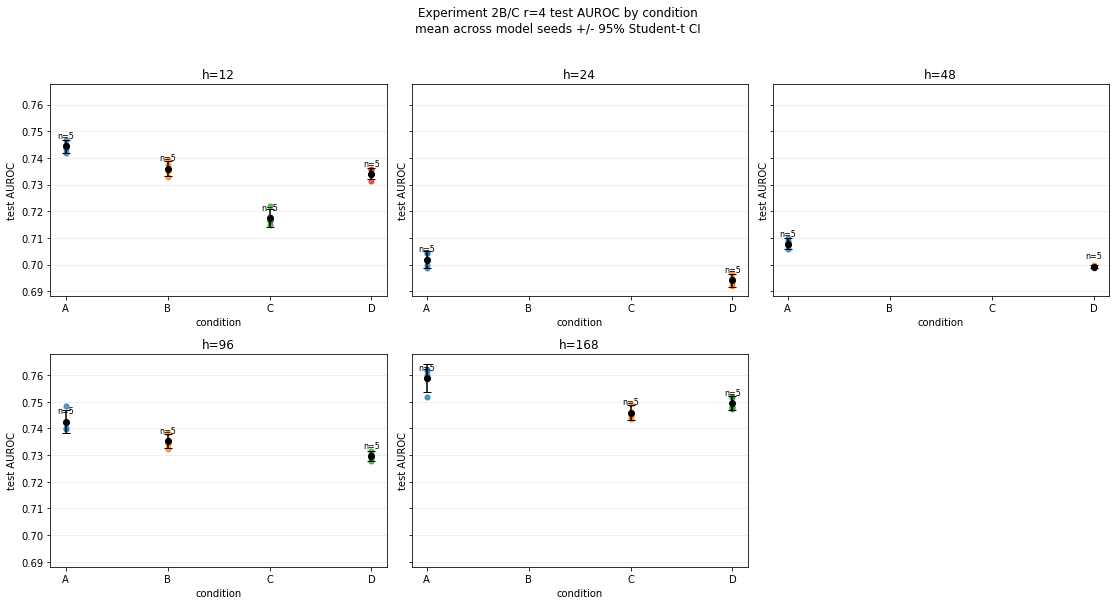

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_test_auroc_by_condition_ci95.png


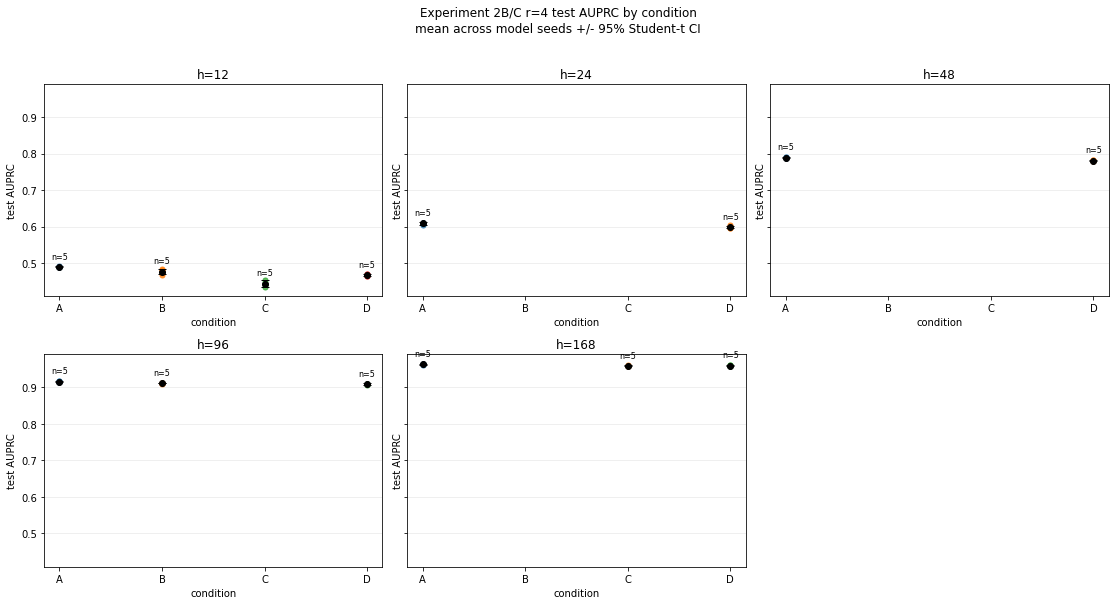

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_test_auprc_by_condition_ci95.png


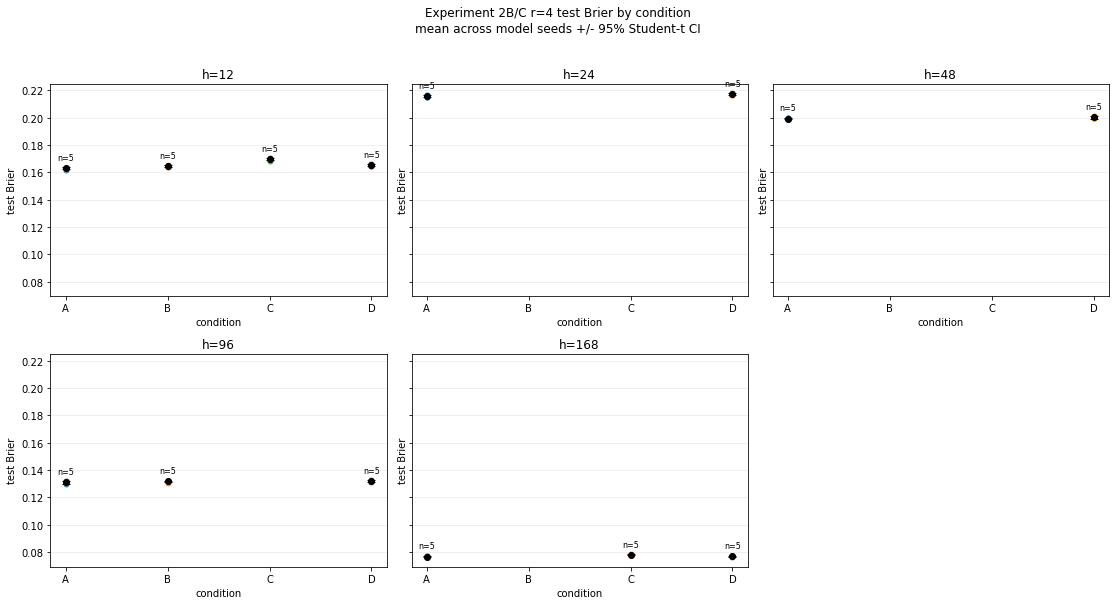

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_test_brier_by_condition_ci95.png


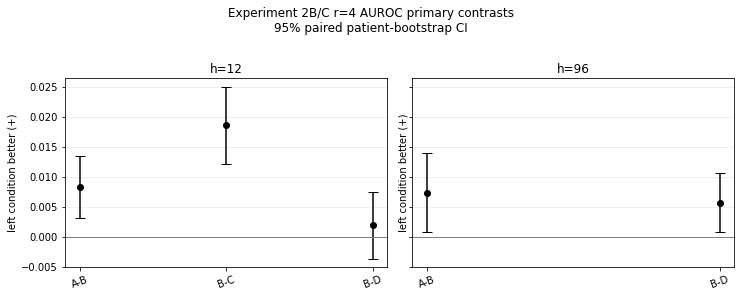

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_auroc_primary_contrasts_bootstrap_ci95.png


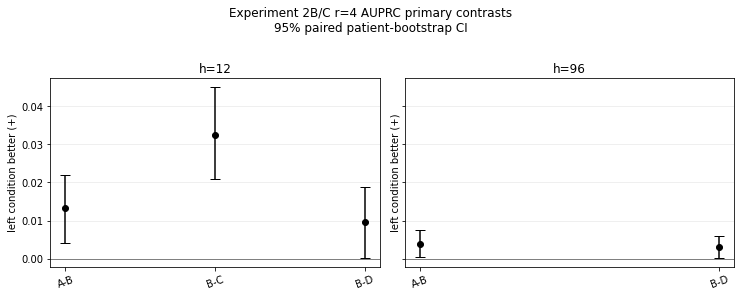

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_auprc_primary_contrasts_bootstrap_ci95.png


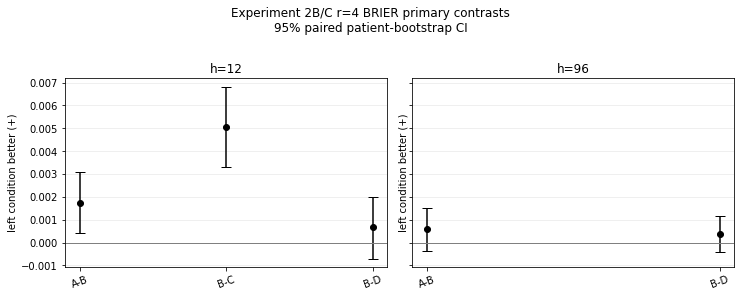

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2b_r4_brier_primary_contrasts_bootstrap_ci95.png
Exp2C severity plot NOT AVAILABLE: fewer than two r values
Exp2C severity plot NOT AVAILABLE: fewer than two r values
Exp2C severity plot NOT AVAILABLE: fewer than two r values


In [ ]:
# ============================================================
# Diagnostic plots
# ============================================================

def _subplot_grid(n_panels, max_cols=3):
    n_cols = min(max_cols, max(1, int(n_panels)))
    n_rows = int(np.ceil(float(n_panels) / float(n_cols)))
    return n_rows, n_cols


def _ordered_horizons(df):
    return sorted(pd.to_numeric(df["horizon"], errors="coerce").dropna().astype(int).unique().tolist())


def _ordered_rs(df):
    return sorted(pd.to_numeric(df["r"], errors="coerce").dropna().astype(int).unique().tolist())


def _contrast_display(label):
    return str(label).replace("_vs_", "-")


def _contrast_order(label):
    wanted = ["{}_vs_{}".format(a, b) for a, b in PRIMARY_CONTRASTS]
    return wanted.index(label) if label in wanted else 999


def plot_metric_by_condition(metric_col, ylabel):
    if not len(run_results):
        return
    for r in _ordered_rs(run_results):
        sub_r = run_results[run_results["r"].astype(int) == int(r)]
        horizons = _ordered_horizons(sub_r)
        if not horizons:
            continue
        n_rows, n_cols = _subplot_grid(len(horizons), max_cols=3)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.1 * n_rows), sharey=True)
        axes = np.asarray(axes).reshape(-1)
        for ax, horizon in zip(axes, horizons):
            sub = sub_r[sub_r["horizon"].astype(int) == int(horizon)]
            metric_summary = summarize_with_t_ci(sub, ["condition"], metric_col)
            x_pos = {cond: i for i, cond in enumerate(CONDITION_ORDER)}
            for cond in CONDITION_ORDER:
                csub = sub[sub["condition"] == cond]
                if len(csub) == 0:
                    continue
                ax.scatter(np.repeat(x_pos[cond], len(csub)), csub[metric_col].values, alpha=0.75, s=26)
                srow = metric_summary[metric_summary["condition"] == cond]
                if len(srow):
                    ax.errorbar(
                        [x_pos[cond]],
                        [srow["mean"].iloc[0]],
                        yerr=[srow["ci95"].fillna(0.0).iloc[0]],
                        fmt="o", linestyle="none", color="black", capsize=4,
                    )
                    ax.annotate("n={}".format(int(srow["n"].iloc[0])),
                                (x_pos[cond], srow["mean"].iloc[0]), xytext=(0, 8),
                                textcoords="offset points", ha="center", fontsize=8)
            ax.set_xticks(range(len(CONDITION_ORDER)))
            ax.set_xticklabels(CONDITION_ORDER)
            ax.set_title("h={}".format(horizon))
            ax.grid(axis="y", alpha=0.25)
            ax.set_xlabel("condition")
            ax.set_ylabel(ylabel)
        for ax in axes[len(horizons):]:
            ax.set_axis_off()
        fig.suptitle("Experiment 2B/C r={} {} by condition\nmean across model seeds +/- 95% Student-t CI".format(r, ylabel), y=1.02)
        fig.tight_layout()
        output_path = EXP2B_OUTPUT_DIR / "experiment2b_r{}_{}_by_condition_ci95.png".format(r, metric_col)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", output_path)


def plot_primary_contrasts(metric):
    if not len(across_seed_summary):
        return
    sub = across_seed_summary[(across_seed_summary["metric"] == metric) & (across_seed_summary["primary"])]
    if len(sub) == 0:
        return
    for r in _ordered_rs(sub):
        sub_r = sub[sub["r"].astype(int) == int(r)]
        horizons = _ordered_horizons(sub_r)
        if not horizons:
            continue
        n_rows, n_cols = _subplot_grid(len(horizons), max_cols=3)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 4.0 * n_rows), sharey=True)
        axes = np.asarray(axes).reshape(-1)
        for ax, horizon in zip(axes, horizons):
            g = sub_r[sub_r["horizon"].astype(int) == int(horizon)].copy()
            if len(g) == 0:
                ax.set_axis_off()
                continue
            g["contrast_order"] = g["contrast"].apply(_contrast_order)
            g = g.sort_values("contrast_order")
            labels = [_contrast_display(x) for x in g["contrast"].tolist()]
            x = np.arange(len(labels))
            y = g["mean_difference"].values
            lo = g["patient_bootstrap_ci_low"].values
            hi = g["patient_bootstrap_ci_high"].values
            yerr = np.nan_to_num(np.vstack([np.maximum(y - lo, 0), np.maximum(hi - y, 0)]), nan=0.0)
            ax.axhline(0, color="gray", linewidth=1)
            ax.errorbar(x, y, yerr=yerr, fmt="o", linestyle="none", capsize=5, color="black")
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=20)
            ax.set_title("h={}".format(horizon))
            ax.set_ylabel("left condition better (+)")
            ax.grid(axis="y", alpha=0.25)
        for ax in axes[len(horizons):]:
            ax.set_axis_off()
        fig.suptitle("Experiment 2B/C r={} {} primary contrasts\n95% paired patient-bootstrap CI".format(r, metric.upper()), y=1.02)
        fig.tight_layout()
        output_path = EXP2B_OUTPUT_DIR / "experiment2b_r{}_{}_primary_contrasts_bootstrap_ci95.png".format(r, metric)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", output_path)


def plot_exp2c_severity(metric):
    if not len(across_seed_summary):
        return
    sub = across_seed_summary[(across_seed_summary["metric"] == metric) & (across_seed_summary["primary"])].copy()
    available_rs = _ordered_rs(sub)
    if len(available_rs) < 2:
        print("Exp2C severity plot NOT AVAILABLE: fewer than two r values")
        return
    fig, axes = plt.subplots(1, len(PRIMARY_CONTRASTS), figsize=(5.0 * len(PRIMARY_CONTRASTS), 4.6), sharey=True)
    axes = np.asarray(axes).reshape(-1)
    plotted_any = False
    for ax, (left, right) in zip(axes, PRIMARY_CONTRASTS):
        contrast = "{}_vs_{}".format(left, right)
        g = sub[sub["contrast"] == contrast].copy()
        if len(g) == 0:
            ax.text(0.5, 0.5, "NOT AVAILABLE", transform=ax.transAxes, ha="center", va="center")
            ax.set_axis_off()
            continue
        horizons = _ordered_horizons(g)
        multi_horizon = len([h for h in horizons if len(g[g["horizon"].astype(int) == int(h)])]) > 1
        for horizon in horizons:
            hsub = g[g["horizon"].astype(int) == int(horizon)].sort_values("r")
            if hsub["r"].nunique() < 2:
                continue
            x = hsub["r"].astype(int).values
            y = hsub["mean_difference"].values
            lo = hsub["patient_bootstrap_ci_low"].values
            hi = hsub["patient_bootstrap_ci_high"].values
            yerr = np.nan_to_num(np.vstack([np.maximum(y - lo, 0), np.maximum(hi - y, 0)]), nan=0.0)
            label = "h={}".format(horizon) if multi_horizon else None
            ax.errorbar(x, y, yerr=yerr, marker="o", capsize=5, linewidth=2, label=label)
            plotted_any = True
        ax.axhline(0, color="gray", linewidth=1)
        ax.set_title(_contrast_display(contrast))
        ax.set_xlabel("r")
        ax.set_ylabel("left condition better (+)")
        ax.set_xticks(available_rs)
        ax.grid(axis="y", alpha=0.25)
        if multi_horizon:
            ax.legend(title="horizon")
    if not plotted_any:
        print("Exp2C severity plot NOT AVAILABLE: fewer than two r values")
        plt.close(fig)
        return
    fig.suptitle("Experiment 2C {} mechanism severity across r\n95% paired patient-bootstrap CI".format(metric.upper()), y=1.02)
    fig.tight_layout()
    output_path = EXP2B_OUTPUT_DIR / "experiment2c_{}_mechanism_vs_r_bootstrap_ci95.png".format(metric)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


plot_metric_by_condition("test_auroc", "test AUROC")
plot_metric_by_condition("test_auprc", "test AUPRC")
plot_metric_by_condition("test_brier", "test Brier")
for metric in METRICS:
    plot_primary_contrasts(metric)
for metric in METRICS:
    plot_exp2c_severity(metric)


# Experiment 2C - Does the mechanism depend on r?

Question: Does the A/B/C/D mechanism change as the frequency reduction becomes more severe, for example r=2, r=4, and r=8?

Quantity: The matched-count code above loops over `TARGET_RS`. If multiple r values are available, the run diagnostics, condition-level summaries, and primary contrast plots are stratified by r.

Evidence we are looking for: The observed results may show little degradation at r=2, moderate effects at r=4, and stronger degradation at r=8, but that pattern is not assumed.

Caveat: Do not fabricate missing r values. Interpret only the r values with complete exact-checkpoint predictions and reported seed availability.

## Stable summary CSV exports

These exports are consumed by `visualize_summary.ipynb`. They only save dataframes already computed by this source notebook; they do not perform discovery, inference, or checkpoint selection.


In [ ]:
# SUMMARY_EXPORTS_EXP2B
SUMMARY_EXPORTS_EXP2B = {
    "status_df": "experiment2b_run_status.csv",
    "partial_df": "experiment2b_partial_runs.csv",
    "missing_predictions_df": "experiment2b_missing_predictions.csv",
    "run_results": "experiment2b_included_prediction_results.csv",
    "run_level": "experiment2b_condition_run_level.csv",
    "summary": "experiment2b_condition_summary.csv",
    "seed_level_contrasts": "experiment2b_seed_level_patient_bootstrap_contrasts.csv",
    "across_seed_summary": "experiment2b_across_seed_contrast_summary.csv",
    "exp2b_input_information_stay_level": "experiment2b_input_information_stay_level.csv",
    "exp2b_input_information_summary": "experiment2b_input_information_summary.csv",
    "exp2b_input_information_channel_retention": "experiment2b_input_information_channel_retention.csv",
}
for _name, _filename in SUMMARY_EXPORTS_EXP2B.items():
    _obj = globals().get(_name)
    if isinstance(_obj, pd.DataFrame):
        _path = EXP2B_OUTPUT_DIR / _filename
        _obj.to_csv(_path, index=False)
        print("exported", _name, "->", _path)
    else:
        print("skipped", _name, "not available")
